# Hands-on AI: From Single Loans to Pool Feature Representation

This notebook accompanies **Chapter 1: The US Mortgage Market**, section **"Machine Learning Bridge: Feature Representation from Single Loans to Pools"**.

## The Core Challenge
In the secondary mortgage market:
1. **Jack and other borrowers** sign individual mortgage contracts with specific note rates, FICO credit scores, LTV ratios, and loan balances.
2. **Lenders and GSEs (Fannie Mae / Freddie Mac)** bundle hundreds or thousands of these variable-sized loans into Mortgage-Backed Security (MBS) pools.
3. **Traders and investors (Elena)** must evaluate the risk, duration, and prepayment sensitivity of the entire pool.

How can a modern Machine Learning model consume a **variable-sized, unordered set of loans** without losing critical credit information?

We compare two representation paradigms:
1. **Classical Hand-Crafted Aggregated Features**: Weighted-average statistics (WAC, WALA, Weighted FICO, Weighted LTV, tail-risk fractions, geographic concentration).
2. **Deep Sets Neural Pool Encoder (Zaheer et al., NeurIPS 2017)**: A permutation-invariant neural set architecture that encodes each loan into a latent representation $\phi(x_i)$, aggregates them via balance-weighted pooling $z_{\text{pool}} = \sum_i w_i \phi(x_i)$, and decodes pool-level risk $\hat{y} = \rho(z_{\text{pool}})$.


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

# Fix thread pool to prevent contention
torch.set_num_threads(4)

# Set seed for exact reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
})

print(f"PyTorch version: {torch.__version__} | Active CPU threads: {torch.get_num_threads()}")


PyTorch version: 2.10.0+cu128 | Active CPU threads: 4


## 1. Simulating Heterogeneous Loan Pools

We generate 300 MBS pools. Each pool contains between 40 and 80 individual loans with realistic micro-attributes:
- **UPB (Unpaid Principal Balance)**: Lognormally distributed around $300,000;
- **Note Rate**: Centered around the pool vintage rate;
- **FICO score**: Credit scores between 620 and 820;
- **LTV (Loan-to-Value)**: Leverage ratios between 45% and 97%;
- **Loan Age**: Months seasoned;
- **State**: One of 5 geographic regions.

**The Economic Ground Truth**:
A borrower's propensity to prepay combines *refinancing financial incentive* with *underwriting credit friction*. Borrowers who have both high rates AND clean credit (high FICO, low LTV) prepay aggressively. Borrowers with low FICO or underwater equity are trapped by credit frictions.


In [2]:
def generate_pools(n_pools=300, min_loans=40, max_loans=80, seed=SEED):
    rng = np.random.default_rng(seed)
    torch.manual_seed(seed)

    pools = []
    pool_targets = []
    classical_features = []

    for pool_id in range(n_pools):
        m = rng.integers(min_loans, max_loans + 1)
        pool_base_rate = rng.uniform(0.058, 0.072)
        pool_avg_fico = rng.uniform(690, 760)

        # Single loan attributes
        upb = rng.lognormal(mean=12.6, sigma=0.4, size=m)
        rates = np.clip(rng.normal(pool_base_rate, 0.003, size=m), 0.050, 0.085)
        ficos = np.clip(rng.normal(pool_avg_fico, 35.0, size=m), 620, 820)
        ltvs = np.clip(rng.normal(74.0, 10.0, size=m), 45.0, 97.0)
        ages = np.clip(rng.poisson(lam=12.0, size=m), 1, 48)
        states = rng.choice(5, size=m, p=[0.25, 0.20, 0.18, 0.12, 0.25])

        # Normalized loan-level feature matrix for Deep Sets
        state_one_hot = np.eye(5)[states]
        norm_loan_features = np.column_stack([
            (rates - 0.065) * 100.0,    # Rate spread from 6.5% in percentage points
            (ficos - 720.0) / 100.0,
            (ltvs - 75.0) / 10.0,
            ages / 12.0,
            state_one_hot,
        ])

        # Balance weights
        weights = upb / np.sum(upb)

        # --- Classical Aggregated Features ---
        wac = np.sum(weights * rates) * 100.0
        wala = np.sum(weights * ages)
        w_fico = np.sum(weights * ficos)
        w_ltv = np.sum(weights * ltvs)
        low_fico_share = np.sum(weights * (ficos < 680))
        high_ltv_share = np.sum(weights * (ltvs > 80))
        state_shares = np.array([np.sum(weights[states == s]) for s in range(5)])
        hhi = np.sum(state_shares ** 2)

        classical_vec = [
            wac, wala, (w_fico - 720.0) / 100.0, (w_ltv - 75.0) / 10.0,
            low_fico_share, high_ltv_share, hhi,
        ]

        # --- Ground Truth Target: Non-linear Prepayment Sensitivity ---
        loan_refi_pot = np.maximum(0.0, rates - 0.060) * 100.0
        credit_friction = 1.0 / (1.0 + np.exp(-(ficos - 680.0) / 25.0)) * (1.0 / (1.0 + np.exp((ltvs - 82.0) / 5.0)))
        loan_true_speeds = 1.0 + 2.5 * loan_refi_pot * credit_friction
        pool_target = float(np.sum(weights * loan_true_speeds)) + rng.normal(0.0, 0.04)

        pools.append({
            "loan_features": torch.tensor(norm_loan_features, dtype=torch.float32),
            "weights": torch.tensor(weights, dtype=torch.float32).unsqueeze(-1),
            "upb": upb,
            "m_loans": m,
        })
        pool_targets.append(pool_target)
        classical_features.append(classical_vec)

    return (
        pools,
        torch.tensor(classical_features, dtype=torch.float32),
        torch.tensor(pool_targets, dtype=torch.float32).unsqueeze(-1),
    )

pools, classical_x, y = generate_pools(n_pools=300)
n_train = 240
train_pools, test_pools = pools[:n_train], pools[n_train:]
x_class_train, x_class_test = classical_x[:n_train], classical_x[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

print(f"Generated {len(pools)} total pools ({n_train} Train, {len(test_pools)} Held-Out Test).")
print(f"Pool #0 Summary: {pools[0]['m_loans']} loans, Total UPB: ${np.sum(pools[0]['upb']):,.0f}")
print(f"  WAC: {classical_x[0, 0]:.2f}%, WALA: {classical_x[0, 1]:.1f} mo, High-LTV: {classical_x[0, 5]*100:.1f}%, HHI: {classical_x[0, 6]:.3f}")


Generated 300 total pools (240 Train, 60 Held-Out Test).
Pool #0 Summary: 43 loans, Total UPB: $13,728,012
  WAC: 6.41%, WALA: 11.8 mo, High-LTV: 23.7%, HHI: 0.207


## 2. Approach A: Classical Aggregated Feature MLP

In traditional quantitative trading, desks condense each pool disclosure tape into a 1D vector of summary moments:
$$x_{\text{classical}} = [\text{WAC}, \text{WALA}, \text{Weighted FICO}, \text{Weighted LTV}, \text{Low-FICO Share}, \text{High-LTV Share}, \text{HHI}_{\text{geo}}]$$

We train a multi-layer perceptron (MLP) on these summary statistics.


In [3]:
class ClassicalMLP(nn.Module):
    def __init__(self, in_features=7, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x)

torch.manual_seed(SEED)
model_classical = ClassicalMLP(in_features=classical_x.shape[1], hidden_dim=32)
opt_class = torch.optim.Adam(model_classical.parameters(), lr=0.01)

losses_class = []
for epoch in range(1, 401):
    opt_class.zero_grad()
    loss = F.mse_loss(model_classical(x_class_train), y_train)
    loss.backward()
    opt_class.step()
    if epoch % 50 == 0:
        losses_class.append((epoch, float(loss.detach())))

with torch.no_grad():
    test_pred_class = model_classical(x_class_test)
    rmse_class = math.sqrt(F.mse_loss(test_pred_class, y_test).item())

print(f"Classical MLP Test RMSE: {rmse_class:.4f}")


Classical MLP Test RMSE: 0.1425


## 3. Approach B: Deep Sets Neural Pool Encoder

The **Deep Sets theorem** states that any permutation-invariant function over a set of elements $\{x_1, \dots, x_M\}$ can be decomposed into:
$$f(\{x_1, \dots, x_M\}) = \rho\left( \sum_{i=1}^M w_i \, \phi(x_i) \right)$$

In mortgage finance:
- $\phi(x_i)$: Encodes Jack's raw loan vector into a 16-dimensional latent representation, capturing non-linear interactions (such as high incentive $\times$ high credit);
- $w_i = \text{UPB}_i / \sum_j \text{UPB}_j$: Balance weight;
- $z_{\text{pool}} = \sum_i w_i \phi(x_i)$: The **learned pool embedding**;
- $\rho(z_{\text{pool}})$: The pool prediction network.


In [4]:
class DeepSetsPoolEncoder(nn.Module):
    def __init__(self, in_loan_features=9, latent_dim=16, hidden_dim=32):
        super().__init__()
        # Loan-level feature encoder phi
        self.phi = nn.Sequential(
            nn.Linear(in_loan_features, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, latent_dim),
        )
        # Pool-level decoder rho
        self.rho = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward_single_pool(self, loan_features, weights):
        loan_embeddings = self.phi(loan_features)
        pool_embedding = torch.sum(weights * loan_embeddings, dim=0, keepdim=True)
        return self.rho(pool_embedding)

    def forward(self, pool_batch):
        preds = [self.forward_single_pool(p["loan_features"], p["weights"]) for p in pool_batch]
        return torch.cat(preds, dim=0)

torch.manual_seed(SEED)
model_deepsets = DeepSetsPoolEncoder(in_loan_features=9, latent_dim=16, hidden_dim=32)
opt_ds = torch.optim.Adam(model_deepsets.parameters(), lr=0.005)

losses_ds = []
for epoch in range(1, 401):
    opt_ds.zero_grad()
    loss = F.mse_loss(model_deepsets(train_pools), y_train)
    loss.backward()
    opt_ds.step()
    if epoch % 50 == 0:
        losses_ds.append((epoch, float(loss.detach())))

with torch.no_grad():
    test_pred_ds = model_deepsets(test_pools)
    rmse_ds = math.sqrt(F.mse_loss(test_pred_ds, y_test).item())

print(f"Deep Sets Neural Pool Encoder Test RMSE: {rmse_ds:.4f}")
print(f"Relative Error Reduction: {((rmse_class - rmse_ds)/rmse_class)*100:.1f}%")


Deep Sets Neural Pool Encoder Test RMSE: 0.0593
Relative Error Reduction: 58.4%


## 4. Empirical Evaluation & Visual Comparison

We plot the out-of-sample predictions of both models against the ground-truth pool prepayment sensitivities.


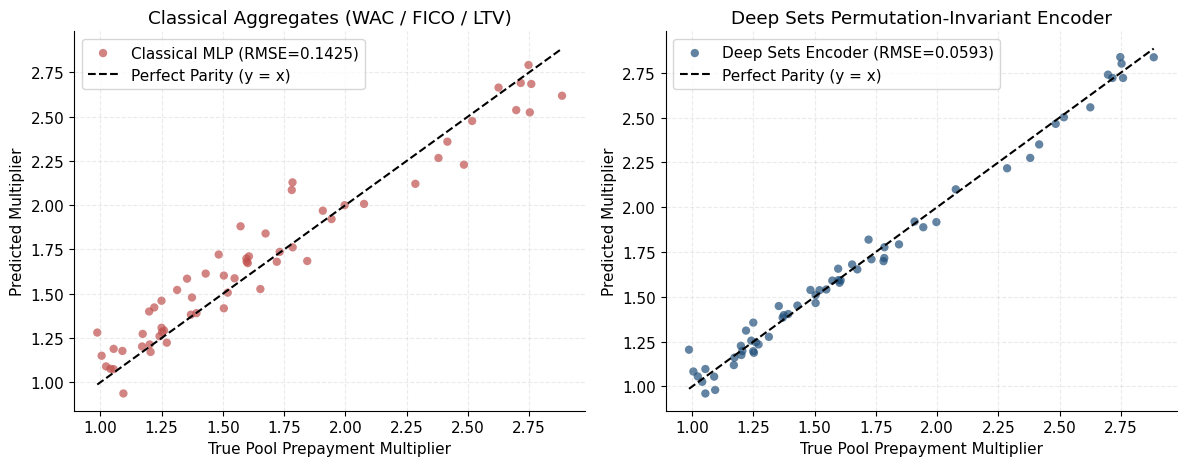

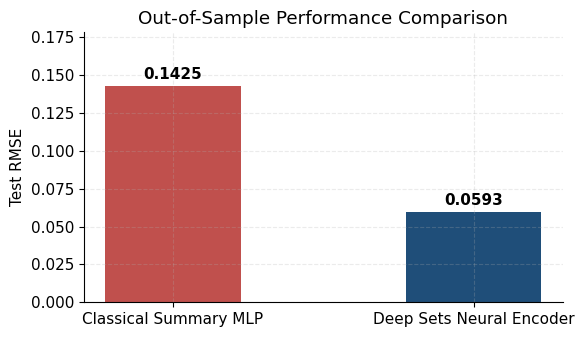

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))

y_test_np = y_test.numpy().flatten()
pred_class_np = test_pred_class.numpy().flatten()
pred_ds_np = test_pred_ds.numpy().flatten()

# Scatter 1: Classical MLP
ax1.scatter(y_test_np, pred_class_np, color="#c0504d", alpha=0.7, edgecolors="none", s=36, label=f"Classical MLP (RMSE={rmse_class:.4f})")
ax1.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()], "k--", lw=1.5, label="Perfect Parity (y = x)")
ax1.set_xlabel("True Pool Prepayment Multiplier")
ax1.set_ylabel("Predicted Multiplier")
ax1.set_title("Classical Aggregates (WAC / FICO / LTV)")
ax1.legend(frameon=True)

# Scatter 2: Deep Sets
ax2.scatter(y_test_np, pred_ds_np, color="#1f4e79", alpha=0.7, edgecolors="none", s=36, label=f"Deep Sets Encoder (RMSE={rmse_ds:.4f})")
ax2.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()], "k--", lw=1.5, label="Perfect Parity (y = x)")
ax2.set_xlabel("True Pool Prepayment Multiplier")
ax2.set_ylabel("Predicted Multiplier")
ax2.set_title("Deep Sets Permutation-Invariant Encoder")
ax2.legend(frameon=True)

plt.tight_layout()
plt.show()

# Comparison summary bar chart
fig, ax = plt.subplots(figsize=(6, 3.5))
models = ["Classical Summary MLP", "Deep Sets Neural Encoder"]
rmses = [rmse_class, rmse_ds]
colors = ["#c0504d", "#1f4e79"]
bars = ax.bar(models, rmses, color=colors, width=0.45)
ax.set_ylabel("Test RMSE")
ax.set_title("Out-of-Sample Performance Comparison")
for bar, val in zip(bars, rmses):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005, f"{val:.4f}", ha="center", fontweight="bold")
ax.set_ylim(0, max(rmses) * 1.25)
plt.tight_layout()
plt.show()


## 5. Quantitative Takeaways for Trading Desks

1. **Information Loss in First Moments**: Hand-crafted summary statistics (WAC, WALA, weighted average FICO/LTV) summarize only the first moments of the distribution. Two pools can have the exact same WAC of 6.50% and average FICO of 740, but one pool might concentrate high-incentive borrowers in low-FICO cohorts (trapped) while the other concentrates them in high-FICO cohorts (ready to refinance tomorrow). Classical aggregates miss this credit cross-dispersion entirely.
2. **Permutation Invariance**: Deep Sets models naturally respect the exchangeability of mortgage disclosure tapes: the order in which loans appear in Fannie Mae's disclosure file has zero financial significance.
3. **Desk Deployment**: On an institutional MBS desk (Elena), Deep Sets representations allow rapid, end-to-end pricing of custom bulk loan packages without losing micro-level borrower heterogeneity.
